<a href="https://colab.research.google.com/github/s0nalagarwal/collision-risk-python-analysis/blob/main/Github_Final_ABT_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="green"><h2> **Mapping Collision Risk in Bay Area Roads**


 ## **By**: Sonal Agarwal, Kara Thomas, Tarilyn Tong, Claire Lee

### **ABT 182 Winter Quarter 2026**

In [45]:
#!pip install leafmap
#!pip install mapclassify

In [30]:
from google.colab import drive
drive.mount('/content/myGdrive')

import geopandas as gpd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from shapely.geometry import box

Drive already mounted at /content/myGdrive; to attempt to forcibly remount, call drive.mount("/content/myGdrive", force_remount=True).


--------------------------------------------
Project Objectives:
---------------------------------------------

* Our goal is to create a function that takes an input of collision data points and street centerline data and will output a color-coded interactive map of roads with high risk of collision. This measure will be based on collisions per length in meters for each road.

* Overall Project workflow:

    *   Read in road and collision data
    *   Set an extent in long/lat and then convert back into a regional CRS.
    *   Crop all datasets to correct extent
    *   Conduct a spatial join based on distance
    *   Find outliers, make boxplots, and other descriptive stats
    *   Merge spatial join dataset back to original roads dataset
    *   Divide counts by length column
    *   Plot based on quantiles, or any other specified break method
    *   Plot on interactive map using leafmap
    *   Make a function that does all of these steps automatically so that this workflow can work for other parts of San Francisco, and other datasets too, if possible.

**Phase 1: Data/ Workflow Exploration**

Step 1:
* Reading in road and collision data, figuring out CRS and extent

(947, 22)


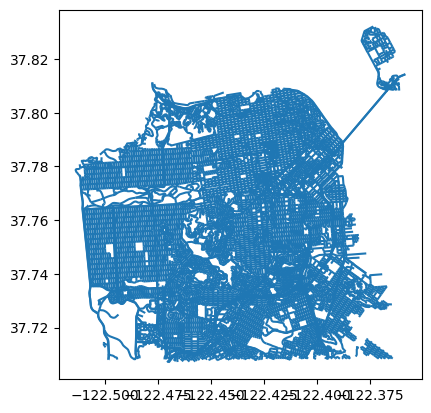

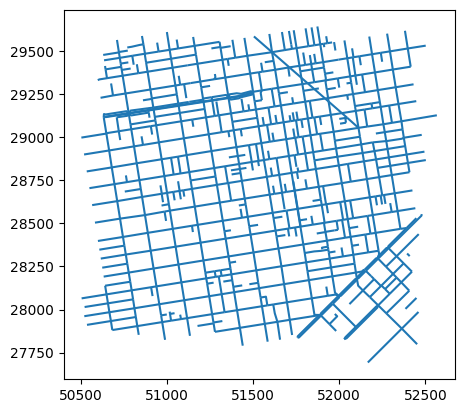

In [31]:

#Read in road data

path = "/content/myGdrive/Shareddrives/ABT_Project_182/Copy of StreetCenterlines.shp"

sf_streets = gpd.read_file(path)
sf_streets.head()

sf_streets.plot()
#This file covers a very large area, lets crop it to a smaller area of SF

xmin, xmax, ymin, ymax = -122.42,-122.40, 37.785,37.800
sf_cropped = sf_streets.cx[xmin:xmax, ymin:ymax] #This is our new extent

#lets reproject to another crs once we have our desired coordinates
sf_cropped.crs
sf_cropped = sf_cropped.to_crs(epsg= 7131)
# This is the: NAD83(2011) / San Francisco CS13, which is in meters
sf_cropped.crs

#Lets plot our cropped roads
sf_cropped.plot()
print(sf_cropped.shape)
sf_cropped.head()

#We need to create a column of road lengths for the subset
sf_cropped['length'] = sf_cropped["geometry"].length





In [32]:
sf_cropped.crs # The units are meters. So the length we have is in meters.

<Projected CRS: EPSG:7131>
Name: NAD83(2011) / San Francisco CS13
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - California - San Francisco bay area - counties of Alameda, Contra Costa, Marin, Napa, San Francisco, San Mateo, Santa Clara, Santa Cruz, Solano and Sonoma.
- bounds: (-123.56, 36.85, -121.2, 38.87)
Coordinate Operation:
- name: City and County of San Francisco CS13 (meter)
- method: Transverse Mercator
Datum: NAD83 (National Spatial Reference System 2011)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

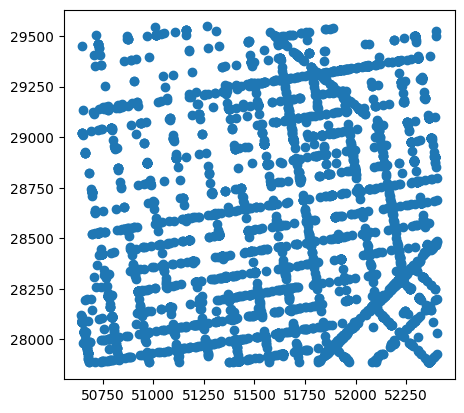

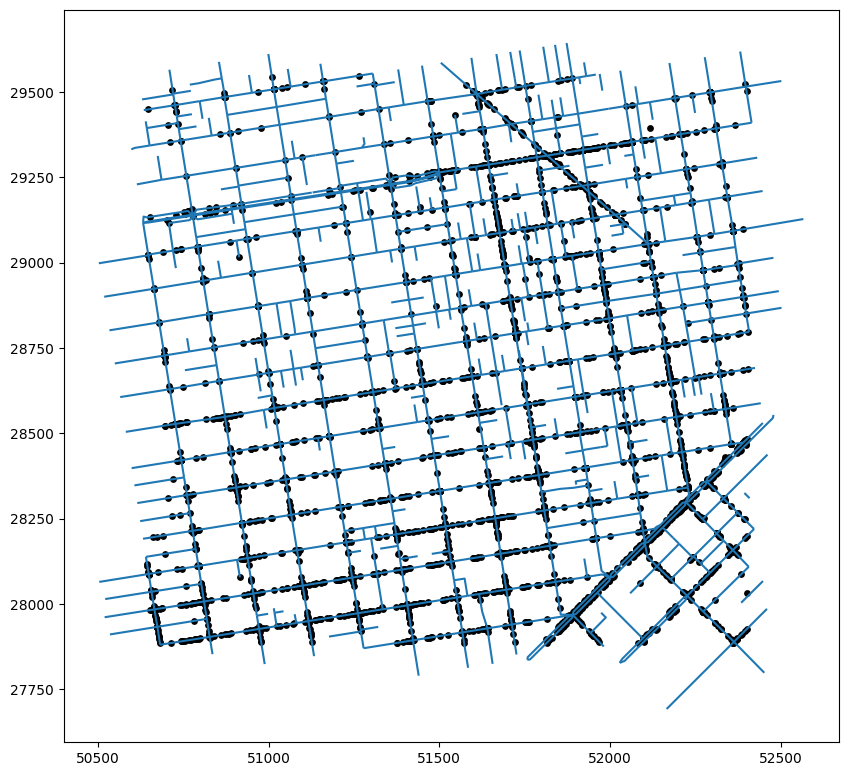

Index(['unique_id', 'cnn_intrsc', 'cnn_sgmt_f', 'case_id_pk', 'tb_latitud',
       'tb_longitu', 'geocode_so', 'geocode_lo', 'date_colli', 'time_colli',
       'date_col_2', 'time_col_2', 'collision_', 'accident_y', 'month',
       'day_of_wee', 'time_cat', 'juris', 'officer_id', 'reporting_',
       'beat_numbe', 'primary_rd', 'secondary_', 'distance', 'direction',
       'weather_1', 'weather_2', 'collisio_2', 'type_of_co', 'mviw',
       'ped_action', 'road_surfa', 'road_cond_', 'road_con_2', 'lighting',
       'control_de', 'intersecti', 'vz_pcf_cod', 'vz_pcf_gro', 'vz_pcf_des',
       'vz_pcf_lin', 'number_kil', 'number_inj', 'street_vie', 'dph_col_gr',
       'dph_col__2', 'party_at_f', 'party1_typ', 'party1_dir', 'party1_mov',
       'party2_typ', 'party2_dir', 'party2_mov', 'date_data_', 'time_data_',
       'date_dat_2', 'time_dat_2', 'date_dat_3', 'time_dat_3', 'analysis_n',
       'supervisor', 'police_dis', 'geometry'],
      dtype='object')


In [33]:
#Read in collision data

path2 = "/content/myGdrive/Shareddrives/ABT_Project_182/geo_export_c1a4cae5-7207-4215-8d55-b1730a30b698.shp"

collisions = gpd.read_file(path2)

#Lets clip the extent of collisions to the same extent of our roads
collisions = collisions.cx[xmin:xmax, ymin:ymax]

#Lets also change the crs to match the cropped streets crs for plotting
collisions = collisions.to_crs(sf_cropped.crs)

#Checking what our dataset looks like
collisions.plot()

#Let's do a quick overlay to see if they match
fig, ax = plt.subplots(figsize = (10,10))

collisions.plot(ax=ax, color= "black", markersize= 15)
sf_cropped.plot(ax=ax)

plt.show()

print(collisions.columns)

#Misc functions to inspect the dataset
#collisions.head()
#print(collisions.shape)
#collisions.columns

**Step 2: Doing a Spatial Join**

* **Objective:** We want to somehow create a measurement of collisions per road, Howevever, not every collision point was exactly on the road centerline.
* To fix this, we tried buffers around the road; however, there was no easy way to ensure that all the points were accounted for.
* Then, we found a geopandas function: gpd.sjoin_nearest(), which allows us to find the nearest road for each collision point.


            street     distances
16           MASON  3.200945e-08
21         MISSION  2.329685e-05
23      SACRAMENTO  1.488909e-05
68            BUSH  4.171047e-05
78          POWELL  7.537756e-05
...            ...           ...
64070       KEARNY  9.684046e-05
64084  LEAVENWORTH  2.352583e+00
64103         04TH  3.541916e-05
64127         03RD  3.796402e-06
64144   CALIFORNIA  2.497732e-05

[5257 rows x 2 columns]
Maximum distance: 25.819430283515565 meters
Minimum distance: 2.9336681169203575e-09 meters


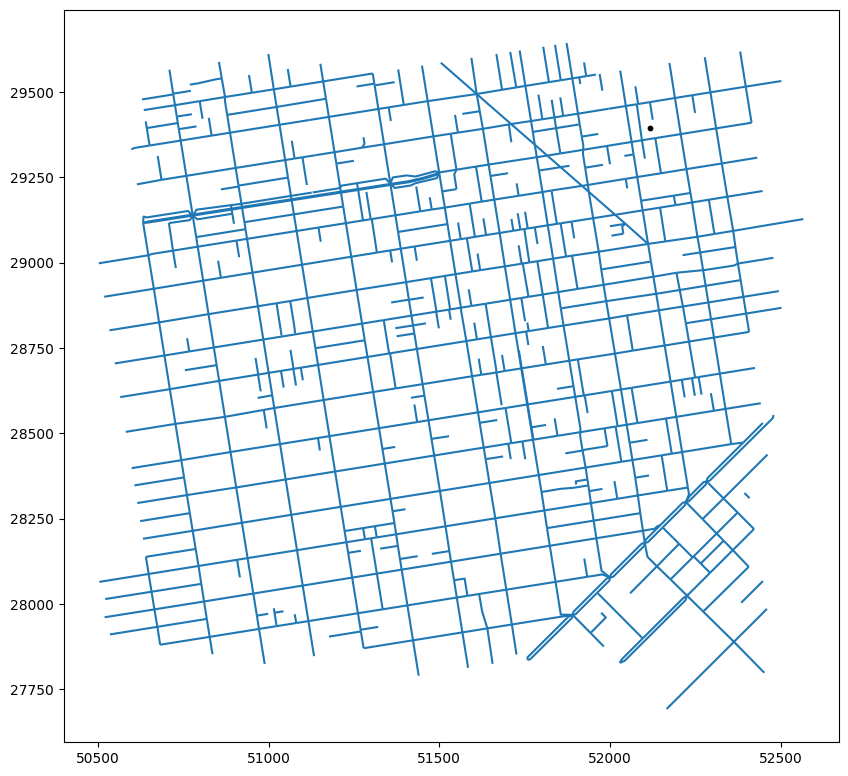

(5257, 87)


In [34]:
#Understanding how the join works

#Our two datasets are:

#print(sf_cropped.head()) #roads
#print("===================================") and
#print(collisions.head()) # collisions

#We want to find for each point, what is the nearest road?
#Since Buffers weren't working as we wanted them to

#switched = gpd.sjoin_nearest(sf_cropped, collisions, how = 'inner', distance_col = "distances")
#this one doesn't make sense

joined = gpd.sjoin_nearest(collisions, sf_cropped, how = "inner",
                           distance_col="distances")
#this looks more correct, assigns each point to a road

print("===================================")

print(joined[["street", "distances"]])  #the numbers are all very small,
# which is a good sign since most of the points sit directly on the roads;
# however, a small number of points don't sit directly on the roads shapefile.

#print(joined.columns)

print("===================================")

# For quality control, let's see what are the min and max values
idx_max = joined['distances'].idxmax()
idx_min = joined['distances'].idxmin()

print(f"Maximum distance: {joined.loc[idx_max, "distances"]} meters")
print(f"Minimum distance: {joined.loc[idx_min, "distances"]} meters")

print("===================================")

#our lowest value is very close to 0, which aligns with the data because a lot
#of points are on the road.
#However, our max is 25 meters, which seems strange. Let's investigate further.

joined["distances"].describe() #all seems fine, let's try to visualize the
#point that is 25 meters

fig, ax = plt.subplots(figsize = (10,10))


joined.loc[[idx_max]].plot(ax = ax, color = "black", markersize = 10)
sf_cropped.plot(ax=ax)

plt.show()

#based on this, we can see that the collision happened in an elementary school,
#meaning that it could've been in a parking lot, drop off, etc. Hence, why it
#is 25 meters away from the nearest road.

#One we way can fix this is by setting a threshold based on the distribution
#(percentiles) of collisions

print(joined.shape)


**Step 3: Finding outliers in the dataset and removing them**

* There are some points which are oddly far from the road (e.g 25  meters ~ 82 feet), which tells us that these collisions may have happened
either at parking lots, unmapped road areas, or are simply errors. We will generate a boxplot to find these outliers. Based on the plot, we can select a threshold to only keep crashes below a certain distance. This can help filter out unhelpful data.


(5256, 87)


8.276636986665405

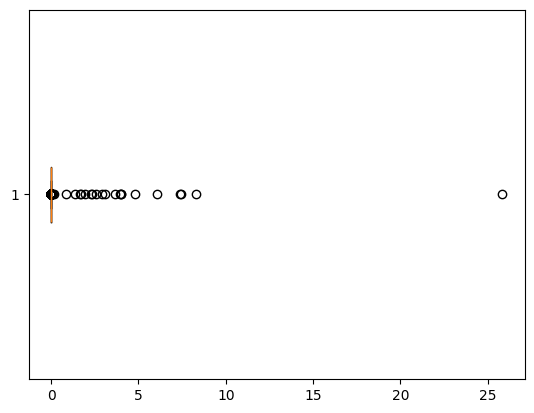

In [35]:
# Finding outliers in the dataset and removing them from the dataset

joined["distances"].describe()

#Create a boxplot to see the outliers
plt.boxplot(joined["distances"], vert = False)

#see which points are above a specific threshold, e.g (10)
joined[joined["distances"] > 10]

#there is only one value above 10, so we can confidently exclude this value

joined = joined[joined["distances"]<10]

print(joined.shape) #making sure row got removed from the dataset

joined["distances"].max()



**Step 4: Count How many Collisions Associated with Each Road**

* Now that we have a dataset telling us which road is closest to each collision, we have to count how many collisions belong to each road in the dataset.
* The roads in this dataset are divided into segments at every intersection. This allows for more accuracy when assesing which specific parts of a road are more dangerous, as some roads span across long distances, and crashes may be clustered at different parts of that road.
* Originally, we had used the "street" column to group by; however, this was causing inaccurate results, so we must group by the index of each line segment created in the spatial join.
* Hence, we will use the "index right" column, as they contain the indexes of each road segment.

In [36]:
# Now lets count how many collisions are associated with each road
# to do this, I will use group by to put the road segments together and count
# how many times the road segment appears in the joined dataset.

print(joined["index_right"])
print("================================")
sample = joined.groupby(by='index_right')

#then for all the segments extract how many times that segment appears in the dataset
#to see how many crashes are associated with that road

for_all_streets = sample['index_right'].size() #size tells us the total number of
#elements in each street segment
print(for_all_streets)
type(for_all_streets)


16        6979
21        6676
23        4343
68       12891
78        4926
         ...  
64070     8264
64084     7745
64103      437
64127      284
64144    12810
Name: index_right, Length: 5256, dtype: int64
index_right
167      29
168       5
169       3
284      35
285      21
         ..
16121     8
16122     1
16225     8
16235    18
16236     3
Name: index_right, Length: 638, dtype: int64


pandas.core.series.Series

**Step 5: Merging Count Information Back Into Streets Dataset for Plottingt**

* Now that we have a dataframe of street names, counts, and distances, we will merge this information back into the original streets dataset for plotting.

In [37]:
# Now we will put this information back into the original streets dataframe,
# (sf_cropped) which can be used for plotting.


print(sf_cropped.columns)

#We must make sure that our streets information is a dataframe and not a series
# before we merge.
for_all_streets = for_all_streets.to_frame()

print(for_all_streets.head())
print("___________________________")
print(sf_cropped.head())
print("___________________________")

for_all_streets.columns = ["counts"] #assigning column name to the new dataframe

print(for_all_streets.head())

#We will merge based on "street", which is the column name both datasets
# have in common

# our left dataset is our geodataframe (roads)
# our right dataset is our counts information (for_all_streets)
# We want to keep the geographic information, so we will merge to the left.

# we will merge using the "index_right" column from our for_all_streets dataset
#, and we will match these keys to the original indexes in the road dataset
# which is why we use left_index = True.
# We are using the column for the right dataset, and the index for the left dataset.

merged = sf_cropped.merge(for_all_streets, right_on = "index_right", left_index = True, how = "left")
#merged.head()

#lets create a new column for collision per meter
merged["collisionpermeter"] = merged["counts"] / merged["length"]

# We will also replace NAs with 0 so that all roads have numeric values.
merged["counts"] = merged["counts"].fillna(0)
merged["collisionpermeter"] = merged["collisionpermeter"].fillna(0)

merged.head()

Index(['accepted', 'classcode', 'cnn', 'cnntext', 'district', 'f_node_cnn',
       'jurisdicti', 'layer', 'lf_fadd', 'lf_toadd', 'multigeom', 'nhood',
       'oneway', 'rt_fadd', 'rt_toadd', 'st_type', 'street', 'street_gc',
       'streetname', 't_node_cnn', 'zip_code', 'geometry', 'length'],
      dtype='object')
             index_right
index_right             
167                   29
168                    5
169                    3
284                   35
285                   21
___________________________
    accepted classcode        cnn  cnntext district  f_node_cnn jurisdicti  \
63         Y         0  2297001.0  2297001     None  30737000.0       None   
64         Y         0  2297002.0  2297002     None  54320000.0       None   
133        N         5  6644000.0  6644000     None  25505000.0        DPW   
162        Y         5  6673000.0  6673000     None  24723000.0        DPW   
167        Y         4   129000.0   129000     None  30734000.0        DPW   

       laye

,index_right,accepted,classcode,cnn,cnntext,district,f_node_cnn,jurisdicti,layer,lf_fadd,...,st_type,street,street_gc,streetname,t_node_cnn,zip_code,geometry,length,counts,collisionpermeter
NaN,63,Y,0,2297001.0,2297001,None,30737000.0,None,UPROW,1.0,...,ST,ANNIE,ANNIE,ANNIE ST,54320000.0,94103,"LINESTRING (52154.403 28224.273, 52185.262 281...",43.507439,0.0,0.000000
NaN,64,Y,0,2297002.0,2297002,None,54320000.0,None,STREETS,19.0,...,ST,ANNIE,ANNIE,ANNIE ST,24617000.0,94105,"LINESTRING (52185.262 28193.603, 52202.583 281...",24.421168,0.0,0.000000
NaN,133,N,5,6644000.0,6644000,None,25505000.0,DPW,STREETS,1.0,...,ST,HAMLIN,HAMLIN,HAMLIN ST,50199000.0,94109,"LINESTRING (50833.37 29371.977, 50825.017 2942...",52.680016,0.0,0.000000
NaN,162,Y,5,6673000.0,6673000,None,24723000.0,DPW,STREETS,1.0,...,PL,HARDIE,HARDIE,HARDIE PL,50228000.0,94104,"LINESTRING (52057.58 28472.463, 52109.916 2848...",53.010637,0.0,0.000000
167.0,167,Y,4,129000.0,129000,None,30734000.0,DPW,STREETS,1.0,...,ST,02ND,2ND,02ND ST,24618000.0,94105,"LINESTRING (52283.033 28359.175, 52332.667 283...",70.303957,29.0,0.412495


**Step 6: Plot the Results**

* We will use the mapclassify package to present our results based on breaks that the user will decide

NaN        0.000000
NaN        0.000000
NaN        0.000000
NaN        0.000000
167.0      0.412495
             ...   
16122.0    0.010154
NaN        0.000000
16225.0    0.071712
16235.0    0.479280
16236.0    0.051837
Name: collisionpermeter, Length: 947, dtype: float64
 Max collisions per meter: 1.0364458427608996
 Min collisions per meter: NaN    0.0
NaN    0.0
NaN    0.0
NaN    0.0
NaN    0.0
      ... 
NaN    0.0
NaN    0.0
NaN    0.0
NaN    0.0
NaN    0.0
Name: collisionpermeter, Length: 309, dtype: float64


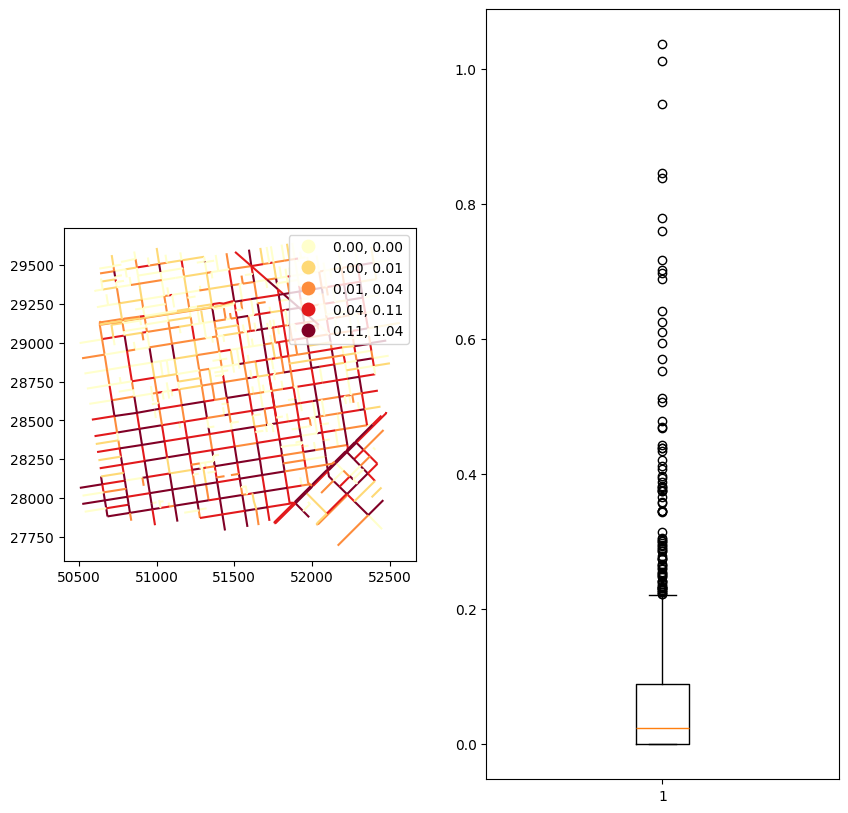

In [38]:
#plotting the final results

#We can plot the counts column instead of collision per meter if we'd like to.
#merged.plot(column = "counts", cmap = "viridis", legend = True)

print(merged["collisionpermeter"])

print("===================================")

#For quality control, let's see what are the min and max values

idx_max = merged['collisionpermeter'].idxmax()
idx_min = merged['collisionpermeter'].idxmin()


print(f" Max collisions per meter: {merged.loc[idx_max, "collisionpermeter"]}")
print(f" Min collisions per meter: {merged.loc[idx_min, "collisionpermeter"]}")

print("===================================")


#Plotting the collision results with a boxplot of the distribution of the values.

fig, ax = plt.subplots(1,2, figsize=(10,10))

merged.plot(ax = ax[0], column = "collisionpermeter", cmap = "YlOrRd", legend = True,
            scheme = "quantiles")
ax[1].boxplot(merged["collisionpermeter"])

plt.show()






**Step 7: Create an Interactive Map Based on Results**

* We can plot our results with leafmap so that the user can zoom in and out, hover over the roads they are interested in, and see the attributes associated with the road.

In [39]:
import leafmap


#We need to convert our linestrings into polygons because for some reason,
#leafmap does not easily allow the default blue border of the linestrings
# to be changed to a colormap; however, it allows this for polygons (we
# referenced lab 9 - GeoAI)

polygons = merged.copy() #making a copy of the merged dataset
polygons["geometry"] = polygons.buffer(5) #creating a polygon based on a
#5 meter buffer of the road


#Plotting with leafmap
#m = leafmap.Map()

#m.add_data( polygons, column="collisionpermeter", cmap="YlOrRd",
           #scheme="quantiles", legend=True,
            #style={"weight": 0.5, "fillOpacity": 1})

#m

**Phase 2: Making a Reproducible Function**

* Now, we want to combine all the major steps into a function that works for any extent in this SF dataset. We can also attempt this function on other city datasets in the Bay Area.

In [40]:
#Lets make it a function now so it's reproducible and can work with any extent

#inputs: roads lines, collisions points, and the bounding box
def dangerous_roads(roads, collisions, xmin, xmax, ymin, ymax):

  """
     Function: Takes an input of collision data points and street centerline
     data and will output a color-coded interactive map of roads with high risk
     of collision. This measure will be based on collisions per length in meters
     for each road.

    Input:
        - roads(vector of roads)
        - collisions(vector of points)
        - xmin, xmax, ymin, ymax (bounding box of area of interest)

    Output:
        - Color-coded interactive map of historical collisions per meter (
          or any other column specified by the user)

  """

  #first, make sure dataset is in long/lat form to crop extent
  roads_cropped = roads.to_crs(epsg = 4326)

  #set roads extent
  roads_cropped = roads_cropped.cx[float(xmin):float(xmax), float(ymin):float(ymax)]

  #project roads to desired CRS - (Greater Bay Area)
  roads_cropped = roads_cropped.to_crs(epsg= 7131)

  #add length column to roads dataframe
  roads_cropped['length'] = roads_cropped["geometry"].length

  #make sure collisions dataset is in long/lat form to crop extent
  collisions = collisions.to_crs(epsg = 4326)

  #set collisions extent
  collisions = collisions.cx[xmin:xmax, ymin:ymax]

  #Lets also change the crs to match the cropped streets crs for plotting
  collisions = collisions.to_crs(roads_cropped.crs)

  #Lets join our collisions to nearest roads
  joined = gpd.sjoin_nearest(collisions, roads_cropped, how = "inner", distance_col="distances")

  # For quality control, let's see what are the min and max values
  idx_max = joined['distances'].idxmax()
  idx_min = joined['distances'].idxmin()

  print(f"Maximum collision distance from road: {joined.loc[idx_max, "distances"]} meters")
  print(f"Minimum collision distance from road: {joined.loc[idx_min, "distances"]} meters")

  print(f" Descriptive Stats: {joined["distances"].describe()}")

  #Create a boxplot to see the outliers
  plt.boxplot(joined["distances"], vert = False)
  plt.ylabel("distance (meters)")
  plt.show()

  #Prompt user to decide if they want to cut off any values based on distribution
  threshold = float(input("Set a threshold to remove outliers. If you would like to keep all values, insert the maximum value"))

  #Remove values above the set threshold
  joined = joined[joined["distances"]< threshold]

  # Group by the index of road segments
  sample = joined.groupby(by= "index_right")

  # Find how many times each road segment appears in the dataset
  for_all_streets = sample["index_right"].size()

  #Convert streets series to a dataframe for spatial merge
  for_all_streets = for_all_streets.to_frame()

  #Rename the column to counts
  for_all_streets.columns = ["counts"]

  #Merge to the left (geodataframe), merge by the index of the roads and by the
  # "index_right" column from the right dataframe
  merged = roads_cropped.merge(for_all_streets, right_on = "index_right", left_index = True, how = "left")

  #lets create a new column for collision per length
  merged["collisionpermeter"] = merged["counts"] / merged["length"]

  #Fill NA values with 0
  merged["counts"] = merged["counts"].fillna(0)
  merged["collisionpermeter"] = merged["collisionpermeter"].fillna(0)

  #Make a boxplot of collisions per meter
  #plt.boxplot(merged["collisionpermeter"])
  #plt.xlabel("collisions per meter")

  #Prompt user to enter column and scheme to map
  column_choice = input("Enter column to map")
  scheme_choice = input("Enter a scheme for mapping")

  #Plot the plot
  merged.plot(column = column_choice, cmap = "YlOrRd", legend = True,
            scheme = scheme_choice)

  #Create a copy of the dataset to turn into polygons for leafmap plotting
  polygons = merged.copy()

  #Create a 5 meter buffer to create a new polygon geometry for the dataset.
  polygons["geometry"] = polygons.buffer(5)

  #Plot leafmap map
  m = leafmap.Map()
  m.add_data( polygons, column= column_choice, cmap="YlOrRd",
           scheme=scheme_choice, legend=True,
            style={"weight": 0.5, "fillOpacity": 1})

  m

  return m




















**Trying Function with a New Extent in SF**

In [41]:
#re-reading in our datasets

path = "/content/myGdrive/Shareddrives/ABT_Project_182/Copy of StreetCenterlines.shp"

sf_streets = gpd.read_file(path)

path2 = "/content/myGdrive/Shareddrives/ABT_Project_182/geo_export_c1a4cae5-7207-4215-8d55-b1730a30b698.shp"

collisions = gpd.read_file(path2)



#Calling our function with a different extent
#dangerous_roads(sf_streets, collisions,-122.5, -122.45, 37.72, 37.73)

**Let's See if Our Function Works with Other City Datasets**


In [42]:
path3 = "/content/myGdrive/MyDrive/ABT182Project/Alameda/Street_Centerlines.shp"

path4 = "/content/myGdrive/MyDrive/ABT182Project/Alameda/crashes.geojson"

oakland_streets = gpd.read_file(path3)
oakland_crash = gpd.read_file(path4)



<Axes: >

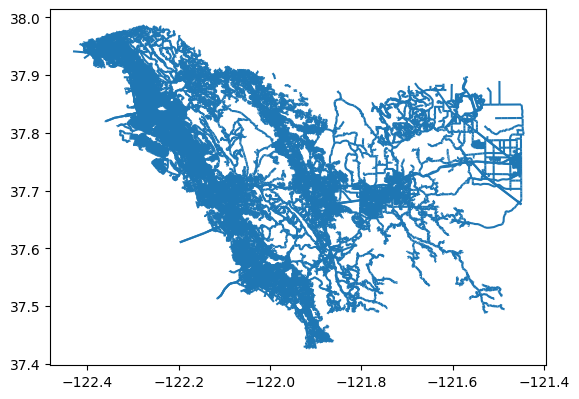

In [43]:
oakland_streets = oakland_streets.to_crs(epsg= 4236)
oakland_streets.plot()

In [44]:
#dangerous_roads(oakland_streets, oakland_crash, -122.3, -122.25, 37.8, 37.85)